<a href="https://colab.research.google.com/github/appsapps555/prj/blob/main/Supplier_Risk%E4%BE%9B%E6%87%89%E5%95%86%E9%A2%A8%E9%9A%AA%E7%AD%89%E7%B4%9A_0708_%E6%95%A3%E4%BD%88%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


# Load the CSV file into a DataFrame
# 手動掛接訓練CSV檔案
# df = pd.read_csv('/content/Data_中英欄位.csv')
df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位.csv')
# df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位_simplifiedFake.csv')
# df
display(df.shape)

# print("Displaying the first 10 rows of 'df' to verify column names:")
# display(df.head(10))

### 繪製 `df_train` 中 'Unit Price' 與 'Quantity' 的散佈圖

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


# Load the CSV file into a DataFrame
# 手動掛接訓練CSV檔案
# df = pd.read_csv('/content/Data_中英欄位.csv')
# df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位.csv')
df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位_simplifiedFake.csv')
# df
display(df.shape)

print("Displaying the first 10 rows of 'df' to verify column names:")
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(49, 2)

Displaying the first 10 rows of 'df' to verify column names:


,Supplier Risk（供應商風險等級）,Supplier Risk Fake（供應商風險等級）
0,Low,Low
1,Low,Medium
2,Medium,Low
3,Low,Low
4,Low,Low
5,Low,Medium
6,Medium,Medium
7,Low,Medium
8,Low,Medium
9,Medium,Low


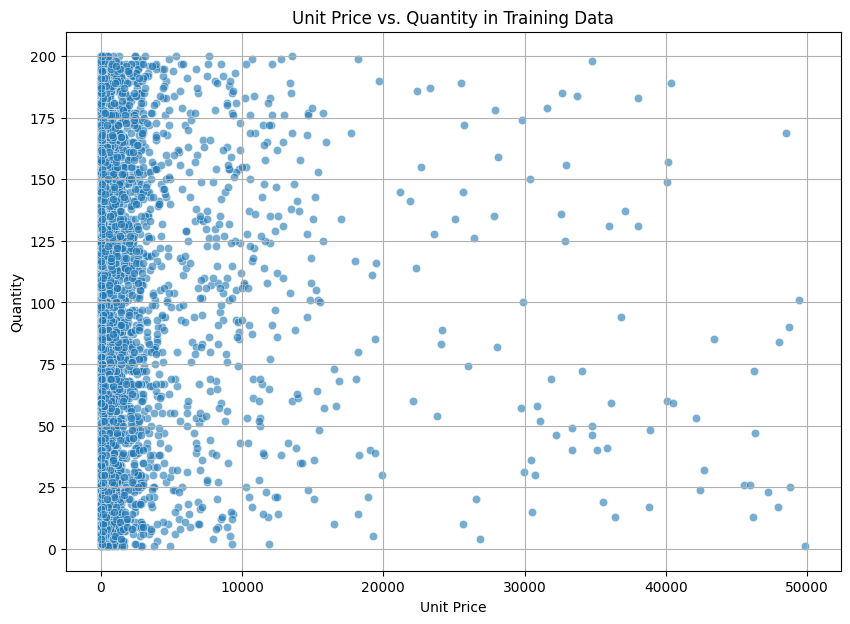

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Unit Price（單價）', y='Quantity（數量）', data=df, alpha=0.6)
plt.title('Unit Price vs. Quantity in Training Data')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

### 針對 'Unit Price' 與 'Quantity' 欄位進行異常值 (Outliers) 檢測

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 檢測 'Unit Price' 的異常值
unit_price_outliers, up_lower, up_upper = detect_outliers_iqr(df_train, 'Unit Price（單價）')
print(f"'Unit Price' 異常值的數量: {len(unit_price_outliers)}")
print(f"'Unit Price' 下限: {up_lower}, 上限: {up_upper}")
display(unit_price_outliers[['Unit Price（單價）', 'Quantity（數量）']].head())

# 檢測 'Quantity' 的異常值
quantity_outliers, q_lower, q_upper = detect_outliers_iqr(df_train, 'Quantity（數量）')
print(f"\n'Quantity' 異常值的數量: {len(quantity_outliers)}")
print(f"'Quantity' 下限: {q_lower}, 上限: {q_upper}")
display(quantity_outliers[['Unit Price（單價）', 'Quantity（數量）']].head())

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

### Check for Missing Values

In [ ]:
# import pandas as pd
# df = pd.read_csv('/content/drive/MyDrive/專題/Data_中英欄位_simplified.csv')
print(df.isnull().sum())

# Optional: Display percentage of missing values
print('\nPercentage of missing values:')
print((df.isnull().sum() / len(df)) * 100)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Assuming 'df' DataFrame is already loaded and available from previous cells.
# If not, please ensure the cell loading the DataFrame (e.g., cell a17dce57) is executed first.

# Define normalization and standardization functions
def min_max_normalize(series):
    if series.empty or series.nunique() == 1:
        return series # Return original if empty or only one unique value
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

def z_score_standardize(series):
    if series.empty or series.std() == 0:
        return series # Return original if empty or standard deviation is zero
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)
'''
'Supplier ESG Score（供應商ESG評分）': 對此數值欄位同時應用了最小-最大正規化 (Supplier ESG Score_Normalized) 和 Z-score 標準化 (Supplier ESG Score_Standardized)，並顯示了前幾行結果。
'Days Late（延誤天數）': 對此數值欄位也同時應用了最小-最大正規化 (Days Late_Normalized) 和 Z-score 標準化 (Days Late_Standardized)，並顯示了前幾行結果。
'On Time Delivery（是否準時交貨）': 這是一個二元類別欄位 (Yes/No)。首先，它被轉換為數值型態 (Yes 為 1，No 為 0) 並儲存在 On Time Delivery_Encoded 欄位中。然後，對這個編碼後的欄位應用了正規化 (On Time Delivery_Normalized) 和標準化 (On Time Delivery_Standardized)，並顯示了前幾行結果。
'PO Status（採購單狀態）', 'Invoice Status（發票狀態）', 'Payment Status（付款狀態）': 這些是多類別名目欄位。程式碼對它們應用了獨熱編碼 (One-Hot Encoding)。這將每個類別轉換為一個新的二元 (0 或 1) 欄位。例如，'PO Status（採購單狀態）' 會被轉換為 PO Status_Cancelled, PO Status_Closed 等欄位，每個欄位表示原始類別是否存在。獨熱編碼後的結果也顯示了前幾行。
'''

print("--- Processing 'Supplier ESG Score（供應商ESG評分）' ---")
df['Supplier ESG Score_Normalized'] = min_max_normalize(df['Supplier ESG Score（供應商ESG評分）'])
df['Supplier ESG Score_Standardized'] = z_score_standardize(df['Supplier ESG Score（供應商ESG評分）'])
display(df[['Supplier ESG Score（供應商ESG評分）', 'Supplier ESG Score_Normalized', 'Supplier ESG Score_Standardized']].head())

print("\n--- Processing 'Days Late（延誤天數）' ---")
df['Days Late_Normalized'] = min_max_normalize(df['Days Late（延誤天數）'])
df['Days Late_Standardized'] = z_score_standardize(df['Days Late（延誤天數）'])
display(df[['Days Late（延誤天數）', 'Days Late_Normalized', 'Days Late_Standardized']].head())

print("\n--- Processing 'On Time Delivery（是否準時交貨）' ---")
# Convert binary categorical to numerical (0/1)
df['On Time Delivery_Encoded'] = df['On Time Delivery（是否準時交貨）'].map({'Yes': 1, 'No': 0})
# Apply normalization and standardization to the encoded column
df['On Time Delivery_Normalized'] = min_max_normalize(df['On Time Delivery_Encoded'])
df['On Time Delivery_Standardized'] = z_score_standardize(df['On Time Delivery_Encoded'])
display(df[['On Time Delivery（是否準時交貨）', 'On Time Delivery_Encoded', 'On Time Delivery_Normalized', 'On Time Delivery_Standardized']].head())

print("\n--- Processing 'PO Status（採購單狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['PO Status（採購單狀態）'], prefix='PO Status')], axis=1)
display(df[[col for col in df.columns if 'PO Status' in col]].head())

print("\n--- Processing 'Invoice Status（發票狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Invoice Status（發票狀態）'], prefix='Invoice Status')], axis=1)
display(df[[col for col in df.columns if 'Invoice Status' in col]].head())

print("\n--- Processing 'Payment Status（付款狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Payment Status（付款狀態）'], prefix='Payment Status')], axis=1)
display(df[[col for col in df.columns if 'Payment Status' in col]].head())

### Standardization and Normalization

In [ ]:
'''
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Function for Min-Max Normalization
def min_max_normalize(series):
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Function for Z-score Standardization
def z_score_standardize(series):
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Example usage: Normalize 'Unit Price（單價）' column
df['Unit Price_Normalized'] = min_max_normalize(df['Unit Price（單價）'])
display(df[['Unit Price（單價）', 'Unit Price_Normalized']].head())

# Example usage: Standardize 'Quantity（數量）' column
df['Quantity_Standardized'] = z_score_standardize(df['Quantity（數量）'])
display(df[['Quantity（數量）', 'Quantity_Standardized']].head())
'''

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

### Display the first 5 rows of the DataFrame

In [ ]:
# display(df.head())

### Display DataFrame information (column names, non-null counts, data types)

In [ ]:
df.info()

### Display descriptive statistics for numerical columns

In [ ]:
display(df.describe())

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Display descriptive statistics of 'Contract Type' grouped by 'Supplier Risk'
# display(df.groupby('Supplier Risk（供應商風險等級）')['Contract Type（合約類型）'].describe())

# Box plot to visualize the distribution of 'Contract Term' across 'Supplier Risk' categories
plt.figure(figsize=(10, 7))
# sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Contract Term（合約期限）', data=df, palette='viridis')
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Contract Type（合約類型）', data=df, palette='viridis')

plt.title('Contract Type Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Contract Type')
plt.show()

### Analyze 'Supplier Risk（供應商風險等級）' Distribution

Supplier Risk Distribution:
 Supplier Risk（供應商風險等級）
Low       3078
Medium    1772
High       350
Name: count, dtype: int64


/tmp/ipykernel_1029/1632704671.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')


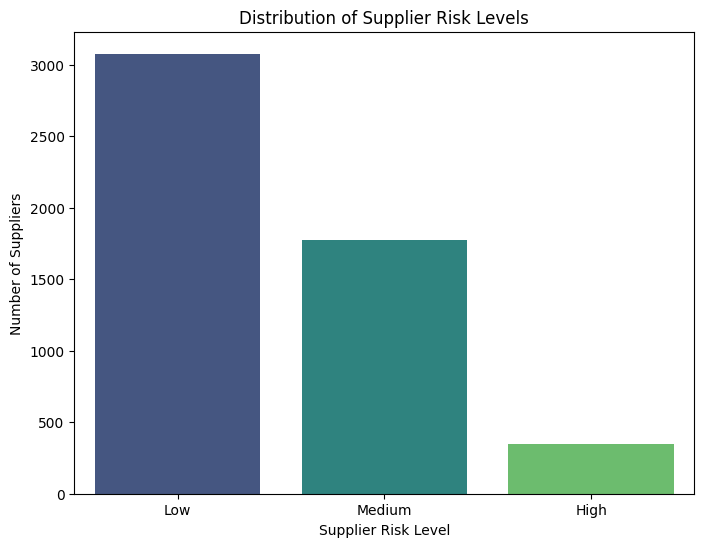

In [ ]:
# Get value counts for 'Supplier Risk'
risk_counts = df['Supplier Risk（供應商風險等級）'].value_counts()
print('Supplier Risk Distribution:\n', risk_counts)

# Plot the distribution of 'Supplier Risk'
plt.figure(figsize=(8, 6))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')
plt.title('Distribution of Supplier Risk Levels')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Number of Suppliers')
plt.show()

### Correlation Heatmap of Numerical Features

In [ ]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Plot the distribution of 'Supplier ESG Score'
plt.figure(figsize=(10, 6))
sns.histplot(df['Supplier ESG Score（供應商ESG評分）'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Supplier ESG Score')
plt.xlabel('Supplier ESG Score')
plt.ylabel('Frequency')
plt.show()

# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Days Late（延誤天數）', y='Supplier ESG Score（供應商ESG評分）', data=df, alpha=0.6)
plt.title('Supplier ESG Score vs. Days Late')
plt.xlabel('Days Late')
plt.ylabel('Supplier ESG Score')
plt.grid(True)
plt.show()

### Analyze 'Supplier ESG Score（供應商ESG評分）' Distribution

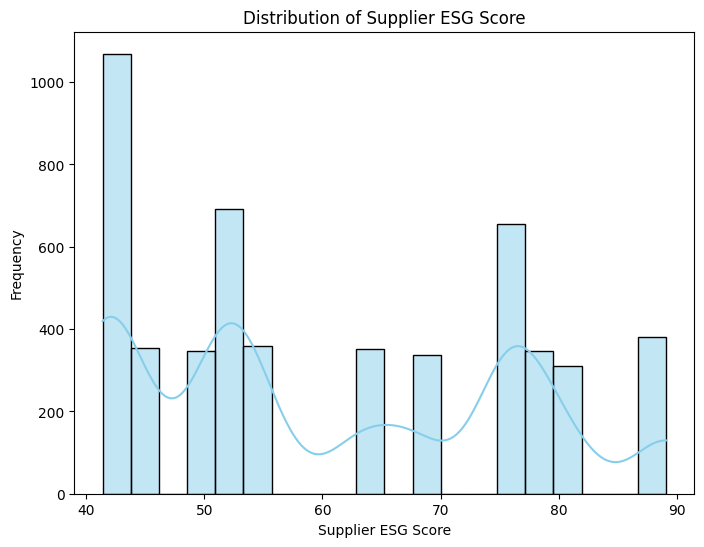

In [ ]:
# Plot the distribution of 'Supplier ESG Score'
plt.figure(figsize=(8, 6))
# sns.histplot(df['Supplier Risk（供應商風險等級）'], bins=20, kde=True, color='skyblue')
sns.histplot(df['Supplier ESG Score（供應商ESG評分）'], bins=20, kde=True, color='skyblue')


plt.title('Distribution of Supplier ESG Score')
plt.xlabel('Supplier ESG Score')
plt.ylabel('Frequency')
plt.show()

## 執行特徵選擇 (Feature Selection)

特徵選擇是機器學習中一個關鍵步驟，它有助於識別對預測目標變數（在這裡是 `Supplier Risk（供應商風險等級）`）最有影響力的特徵。這可以減少模型的複雜性、防止過度擬合，並提高模型的解釋性。

由於我們的目標變數是類別型（'Low'、'Medium'、'High'），我們將使用適合分類問題的特徵選擇方法。我們將採用以下步驟：

1.  **編碼目標變數**：將 `Supplier Risk（供應商風險等級）` 從類別型 ('Low', 'Medium', 'High') 轉換為序數數值型態 (0, 1, 2)。
2.  **準備特徵矩陣**：處理所有特徵欄位，確保它們都是數值型。對於尚未進行獨熱編碼的類別型特徵，我們將對其進行獨熱編碼。
3.  **使用 `SelectKBest` 進行統計特徵選擇**：此方法使用統計檢定來評估每個特徵與目標變數之間的關係。對於分類目標，我們通常使用 ANOVA F-value (f_classif)。
4.  **使用 `RandomForestClassifier` 獲取特徵重要性**：基於樹的模型（如隨機森林）可以自然地為每個特徵提供一個重要性分數，表示該特徵在模型中預測目標的貢獻程度。
5.  **視覺化結果**：繪製圖表來展示特徵重要性，以便更容易地識別關鍵特徵。

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# 1. 編碼目標變數 'Supplier Risk（供應商風險等級）'
# 由於風險等級有內在順序，使用 OrdinalEncoder 或手動映射都可以
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Supplier Risk_Encoded'] = df['Supplier Risk（供應商風險等級）'].map(risk_mapping)

display(df[['Supplier Risk（供應商風險等級）', 'Supplier Risk_Encoded']].head())

,Supplier Risk（供應商風險等級）,Supplier Risk_Encoded
0,Low,0
1,Low,0
2,Medium,1
3,Low,0
4,Low,0


In [ ]:
import numpy as np

# 2. 準備特徵矩陣 X 和目標向量 y
y = df['Supplier Risk_Encoded']

# 排除目標變數本身、編碼後的目標變數、以及識別碼和已處理的原始類別變數
columns_to_drop = [
    'PO Number（採購單號）', 'PO Date（採購單日期）', # 識別碼/日期
    'Supplier Risk（供應商風險等級）', 'Supplier Risk_Encoded', # 原始和編碼後的目標變數
    'On Time Delivery（是否準時交貨）', # 已有 On Time Delivery_Encoded
    'PO Status（採購單狀態）', # 已有 PO Status_X 獨熱編碼欄位
    'Invoice Status（發票狀態）', # 已有 Invoice Status_X 獨熱編碼欄位
    'Payment Status（付款狀態）' # 已有 Payment Status_X 獨熱編碼欄位
]

X = df.drop(columns=columns_to_drop, errors='ignore')

# 處理 X 中剩餘的非數值欄位 (如果還有)
# 這裡我們識別所有 object 類型且不是已經是獨熱編碼的欄位
categorical_cols_for_ohe = X.select_dtypes(include='object').columns

if not categorical_cols_for_ohe.empty:
    print(f"Performing One-Hot Encoding for remaining categorical columns: {list(categorical_cols_for_ohe)}")
    X = pd.get_dummies(X, columns=categorical_cols_for_ohe, drop_first=True)
else:
    print("No additional categorical columns found for One-Hot Encoding.")

# 確保所有 NaN 值都被處理，例如填充為0或平均值，因為特徵選擇方法通常不接受 NaN
# 對於 `f_classif` 和 `RandomForestClassifier`，NaN 必須被處理
# 這裡我們簡單填充為0，實際應用中應根據資料性質選擇更合適的填充策略
X = X.fillna(0)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of prepared features (X):")
display(X.head())

Performing One-Hot Encoding for remaining categorical columns: ['PO Quarter（採購季度）', 'PO Month（採購月份）', 'PO Type（採購單類型）', 'Supplier ID（供應商編號）', 'Supplier Name（供應商名稱）', 'Supplier Country（供應商國家）', 'Supplier Region（供應商地區）', 'Supplier Status（供應商狀態）', 'Payment Terms（付款條件）', 'Item Code（品項代碼）', 'Item Description（品項描述）', 'Category（品類）', 'Sub Category（子品類）', 'Unit of Measure（計量單位）', 'Currency（幣別）', 'Requested Delivery（要求交貨日）', 'Actual Delivery（實際交貨日）', 'Department（部門）', 'Cost Centre（成本中心）', 'Requestor Name（請購人姓名）', 'Approver Name（核准人姓名）', 'Contract ID（合約編號）', 'Contract Type（合約類型）', 'Contract Start（合約起始日）', 'Contract End（合約結束日）', 'Invoice Match Type（發票勾稽類型）', 'Maverick Spend（脫軌採購）', 'Single Source Flag（單一來源標記）', 'Preferred Supplier（優先供應商）', 'Local International（本地／國際）']
Features (X) shape: (5200, 8376)
Target (y) shape: (5200,)
First 5 rows of prepared features (X):


,PO Year（採購年度）,Supplier Tier（供應商層級）,Supplier Latitude（供應商緯度）,Supplier Longitude（供應商經度）,Unit Price（單價）,Quantity（數量）,Discount Pct（折扣百分比）,Discount Amount（折扣金額）,Tax Pct（稅率百分比）,Tax Amount（稅額）,...,Contract End（合約結束日）_31/12/2022,Contract End（合約結束日）_31/12/2023,Contract End（合約結束日）_31/12/2024,Contract End（合約結束日）_31/12/2025,Invoice Match Type（發票勾稽類型）_3-Way Match,Invoice Match Type（發票勾稽類型）_No Match,Maverick Spend（脫軌採購）_Yes,Single Source Flag（單一來源標記）_Yes,Preferred Supplier（優先供應商）_Yes,Local International（本地／國際）_Local
0,2024,1,35.9078,127.7669,6.55,41,0,0.00,5,13.43,...,False,False,False,False,True,False,False,False,True,False
1,2024,2,55.3781,-3.4360,34756.85,198,0,0.00,0,0.00,...,False,False,False,False,False,False,False,False,False,True
2,2024,3,51.9194,19.1451,367.54,197,5,3620.27,0,0.00,...,False,False,False,False,False,False,False,False,False,False
3,2023,2,60.1282,18.6435,97.92,36,0,0.00,0,0.00,...,False,False,False,False,False,False,False,False,False,False
4,2022,1,51.1657,10.4515,33.06,88,0,0.00,5,145.46,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# 3. 使用 SelectKBest 和 f_classif 進行特徵選擇
# 選擇前 k 個最佳特徵，這裡我們選擇 20 個作為範例
k_best_features = 20
selector = SelectKBest(score_func=f_classif, k=k_best_features)

# 注意：f_classif 要求輸入為非負數，如果 X 中有負數，可能會報錯。
# 我們已經填充 NaN 為 0，但如果原始資料有負數，需額外處理。
X_new = selector.fit_transform(X, y)

# 獲取選定的特徵名稱
selected_features_kbest = X.columns[selector.get_support()]

print(f"Selected {k_best_features} features using SelectKBest (f_classif):")
print(list(selected_features_kbest))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Selected 20 features using SelectKBest (f_classif):
['Supplier Tier（供應商層級）', 'Supplier Latitude（供應商緯度）', 'Supplier Longitude（供應商經度）', 'Supplier ID（供應商編號）_SUP-003', 'Supplier ID（供應商編號）_SUP-011', 'Supplier ID（供應商編號）_SUP-013', 'Supplier Name（供應商名稱）_Atlantic Raw Materials', 'Supplier Name（供應商名稱）_GlobalParts Ltd', 'Supplier Name（供應商名稱）_Meridian Tech', 'Supplier Name（供應商名稱）_Quantum Electronics', 'Supplier Country（供應商國家）_Brazil', 'Supplier Country（供應商國家）_China', 'Supplier Country（供應商國家）_India', 'Supplier Country（供應商國家）_Taiwan', 'Supplier Region（供應商地區）_Asia', 'Supplier Status（供應商狀態）_Conditional', 'Supplier Status（供應商狀態）_Preferred', 'Payment Terms（付款條件）_Net 60', 'Maverick Spend（脫軌採購）_Yes', 'Preferred Supplier（優先供應商）_Yes']


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 4. 使用 RandomForestClassifier 獲取特徵重要性
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 獲取特徵重要性
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# 根據重要性排序
sorted_importances = feature_importances.sort_values(ascending=False)

print("Top 20 features by RandomForestClassifier importance:")
display(sorted_importances.head(20))

Top 20 features by RandomForestClassifier importance:


,0
Supplier Tier（供應商層級）,0.056331
Payment Terms（付款條件）_Net 60,0.050987
Supplier Latitude（供應商緯度）,0.050059
Supplier Longitude（供應商經度）,0.050046
Supplier ESG Score（供應商ESG評分）,0.043153
Supplier Status（供應商狀態）_Preferred,0.042028
Preferred Supplier（優先供應商）_Yes,0.034765
Supplier Region（供應商地區）_Asia,0.034303
Supplier Country（供應商國家）_Brazil,0.033490
Supplier ID（供應商編號）_SUP-011,0.029422


/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 20379 (\N{CJK UNIFIED IDEOGRAPH-4F9B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 25033 (\N{CJK UNIFIED IDEOGRAPH-61C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 32026 (\N{CJK UNIFIED IDEOGRAPH-7D1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/171823019.py:8: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing fro

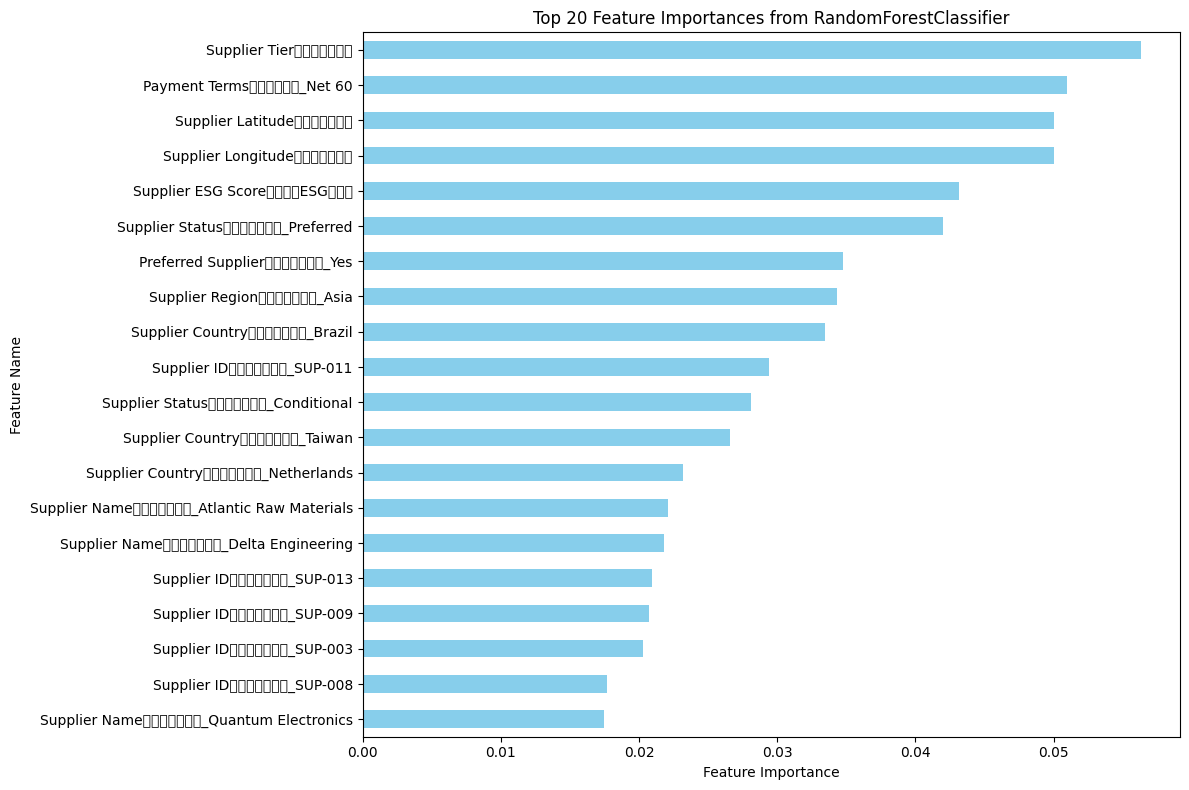

In [ ]:
# 5. 視覺化 RandomForestClassifier 的特徵重要性
plt.figure(figsize=(12, 8))
sorted_importances.head(20).plot(kind='barh', color='skyblue')
plt.title('Top 20 Feature Importances from RandomForestClassifier')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.gca().invert_yaxis() # 將最重要的特徵放在頂部
plt.tight_layout()
plt.show()

### 特徵選擇結果摘要

透過上述兩種方法（`SelectKBest` 與 `RandomForestClassifier`）進行特徵選擇，我們現在可以識別出對預測「供應商風險等級」最重要的欄位。您將能夠從 `SelectKBest` 的輸出列表中看到統計上最顯著的特徵，以及從隨機森林模型中看到最具預測力的特徵（通常會以條形圖的形式呈現）。

這些結果可以指導您在後續的模型訓練中選擇使用哪些特徵，從而建立更精簡、更高效的風險預測模型。

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Supplier ESG Score（供應商ESG評分）'

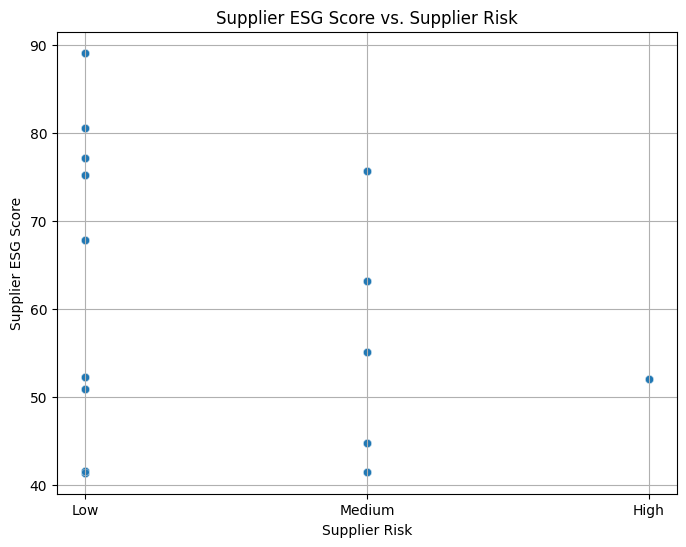

/tmp/ipykernel_1029/1615306778.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, palette='viridis')


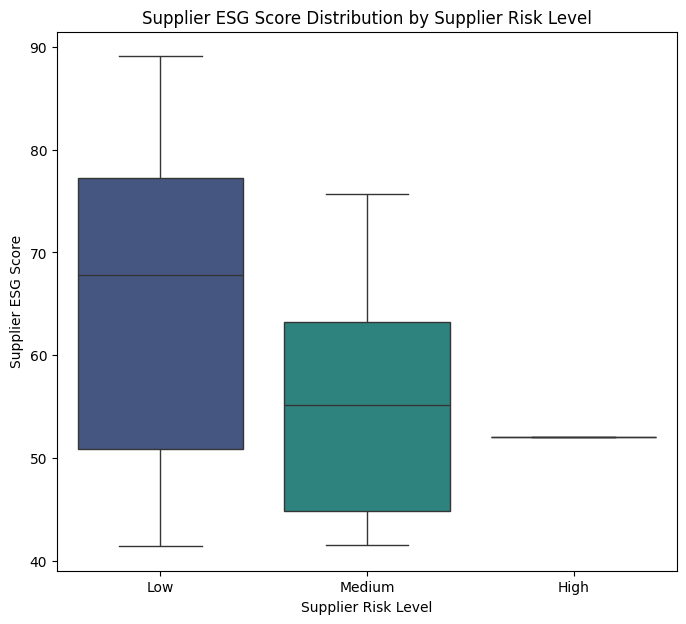

In [ ]:
# Add a scatter plot of 'Supplier ESG Score' vs. 'Supplier Risk'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, alpha=0.6)
plt.title('Supplier ESG Score vs. Supplier Risk')
plt.xlabel('Supplier Risk')
plt.ylabel('Supplier ESG Score')
plt.grid(True)
plt.show()


# Box plot to visualize the distribution of 'Supplier ESG Score' across 'Supplier Risk' categories
plt.figure(figsize=(8, 7))
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, palette='viridis')
plt.title('Supplier ESG Score Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Supplier ESG Score')
plt.show()

In [ ]:
'''Using crosstab plot'''

# Create a cross-tabulation of 'Supplier Risk' and 'Supplier ESG Score'
crosstab_po_type = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Supplier ESG Score（供應商ESG評分）'])
display(crosstab_po_type)

# Visualize the relationship with a stacked bar plot
crosstab_po_type.plot(kind='bar', stacked=True, figsize=(8, 7))
plt.title('Supplier Risk by ESG Score')
plt.xlabel('Supplier Risk')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Supplier ESG Score')
plt.tight_layout()
plt.show()

### Relationship between 'PO Status（採購單狀態）' and 'PO Type（採購單類型）'

In [ ]:
'''
# Create a cross-tabulation of 'PO Status' and 'PO Type'
crosstab_po_type = pd.crosstab(df['PO Status（採購單狀態）'], df['PO Type（採購單類型）'])
display(crosstab_po_type)

# Visualize the relationship with a stacked bar plot
crosstab_po_type.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('PO Status by PO Type')
plt.xlabel('PO Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='PO Type')
plt.tight_layout()
plt.show()'''

### 顯示訓練數據集 (`df_train`) 的描述性統計資訊

In [ ]:
display(df_train.describe())

# 不適合使用PO Status作為Y應變數的原因

In [ ]:
# Get value counts for 'PO Status'
po_status_counts = df['PO Status（採購單狀態）'].value_counts()
print('PO Status Distribution:\n', po_status_counts)

# Plot the distribution of 'PO Status'
plt.figure(figsize=(8, 6))
sns.barplot(x=po_status_counts.index, y=po_status_counts.values, palette='coolwarm')
plt.title('Distribution of PO Status')
plt.xlabel('PO Status')
plt.ylabel('Number of Purchase Orders')
plt.show()



# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Supplier Risk（供應商風險等級）', y='PO Status（採購單狀態）', data=df, alpha=0.6)
plt.title('PO Status vs. Supplier Risk')
plt.xlabel('Supplier Risk')
plt.ylabel('PO Status')
plt.grid(True)
plt.show()

### Analyze 'Days Late（延誤天數）' Distribution

In [ ]:
# Get value counts for 'Days Late（延誤天數）'
po_status_counts = df['Days Late（延誤天數）'].value_counts()
print('Days Late Distribution:\n', po_status_counts)

# Plot the distribution of 'Days Late'
plt.figure(figsize=(8, 6))
sns.barplot(x=po_status_counts.index, y=po_status_counts.values, palette='coolwarm')
plt.title('Distribution of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Number of Purchase Orders')
plt.show()

In [ ]:
'''
# Get value counts for 'Days Late（延誤天數）'
days_late_cnt = df['Days Late（延誤天數）'].value_counts()
print('Days Late Distribution:\n', days_late_cnt)
'''


# Plot the distribution of 'Days Late'
plt.figure(figsize=(8, 6))
sns.histplot(df['Days Late（延誤天數）'], bins=40, kde=True, color='lightcoral')
plt.title('Distribution of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
plt.show()



### Relationship between 'Supplier Risk（供應商風險等級）' and 'Days Late（延誤天數）'

In [ ]:
# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Days Late（延誤天數）', y='Supplier Risk（供應商風險等級）', data=df, alpha=0.6)
plt.title('Supplier Risk vs. Days Late')
plt.xlabel('Days Late')
plt.ylabel('Supplier Risk')
plt.grid(True)
plt.show()


# Box plot to visualize the distribution of 'Days Late' across 'Supplier Risk' categories
plt.figure(figsize=(10, 7))
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Days Late（延誤天數）', data=df, palette='coolwarm')
plt.title('Days Late Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Days Late')
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'On Time Delivery（是否準時交貨）'

In [ ]:
# Cross-tabulation
crosstab_on_time = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['On Time Delivery（是否準時交貨）'])
display(crosstab_on_time)

# Stacked bar chart
crosstab_on_time.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by On Time Delivery')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='On Time Delivery')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'PO Status（採購單狀態）'

In [ ]:
# Cross-tabulation
crosstab_po_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['PO Status（採購單狀態）'])
display(crosstab_po_status)

# Stacked bar chart
crosstab_po_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by PO Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='PO Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Invoice Status（發票狀態）'

In [ ]:
# Cross-tabulation
crosstab_invoice_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Invoice Status（發票狀態）'])
display(crosstab_invoice_status)

# Stacked bar chart
crosstab_invoice_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Invoice Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Invoice Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Payment Status（付款狀態）'

In [ ]:
# Cross-tabulation
crosstab_payment_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Payment Status（付款狀態）'])
display(crosstab_payment_status)

# Stacked bar chart
crosstab_payment_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Payment Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Payment Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Supplier Tier（供應商層級）'

In [ ]:
# Cross-tabulation
crosstab_supplier_tier = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Supplier Tier（供應商層級）'])
display(crosstab_supplier_tier)

# Stacked bar chart
crosstab_supplier_tier.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Supplier Tier')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Supplier Tier')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Maverick Spend（脫軌採購）'

In [ ]:
# Cross-tabulation
crosstab_maverick = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Maverick Spend（脫軌採購）'])
display(crosstab_maverick)

# Stacked bar chart
crosstab_maverick.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Maverick Spend')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Maverick Spend')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Single Source Flag（單一來源標記）'

In [ ]:
# Cross-tabulation
crosstab_single_source = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Single Source Flag（單一來源標記）'])
display(crosstab_single_source)

# Stacked bar chart
crosstab_single_source.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Single Source Flag')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Single Source Flag')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Preferred Supplier（優先供應商）'

In [ ]:
# Cross-tabulation
crosstab_preferred = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Preferred Supplier（優先供應商）'])
display(crosstab_preferred)

# Stacked bar chart
crosstab_preferred.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Preferred Supplier')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Preferred Supplier')
plt.tight_layout()
plt.show()